In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

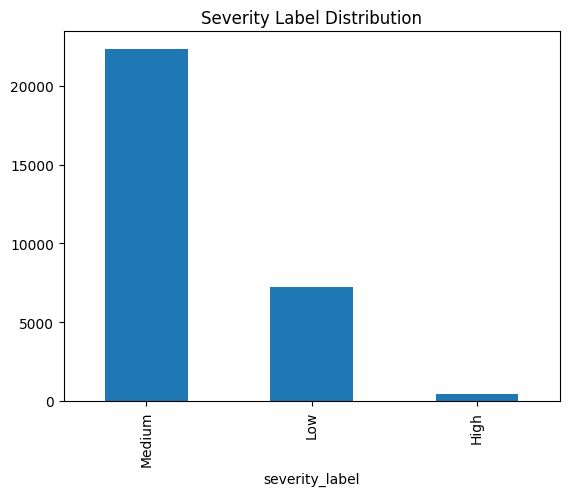

In [2]:
df = pd.read_csv("D:/SALEM/Machine Learning Models/2-Incident Severity Prediction/Dataset/incident_severity_dataset.csv")

df["severity_label"].value_counts().plot(
    kind="bar", title="Severity Label Distribution"
)
plt.show()

In [3]:
features = [
    "citizen_trust_score",
    "anomaly_score",
    "image_authenticity_score",
    "reports_nearby_1h",
    "historical_severity_avg"
]

X = df[features]
y = df["severity_label"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [6]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      0.53      0.69        98
         Low       0.97      0.96      0.96      1490
      Medium       0.98      0.99      0.98      4412

    accuracy                           0.97      6000
   macro avg       0.98      0.83      0.88      6000
weighted avg       0.97      0.97      0.97      6000



In [10]:
import joblib
joblib.dump(model, "D:/SALEM/Machine Learning Models/2-Incident Severity Prediction/modelpk/severity_model.pkl")
print("✅ Trust model saved")

✅ Trust model saved


In [ ]:
df["predicted_severity"] = model.predict(X)
df.to_csv("/severity_predictions.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'D:\SALEM\Machine Learning Models\2-Incident Severity Predictions\modelpk'